# Mandatory: Supervised Learning II
# Student Performance Training Models
In this document we'll be training different machine learning models to predict student performance based on the processed dataset from the previous notebook and the original provided dataset.

### Goals in this Notebook:
- Randomly split the data into train/validation/test.
    - Since we're working with a slightly larger dataset than before, I've chosen to set aside a part of the data for validation to make sure the test data is completely unseen during model selection and hyperparameter tuning.
- Use automated hyperparameter tuning to find strong classifiers.
- Evaluate models with accuracy, precision, recall, and F1.
- Optimize the decision threshold of the best classifier for perfect precision and maximal recall.

### Package Imports and Data Loading
We start by importing necessary packages and loading both the original and processed datasets.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns


### Custom Features
The cell below contains custom functions which is intented to simplify repetitive tasks such as model training, evaluation, and threshold optimization.  
Some of these functions has been copied from previous notebooks or from notebooks supplied through the course, so there might be some overlap with code you've seen before.
#### Function descriptions:
- `stvts`:
    - Splits data into train, validation, and test sets.  
    Val/test size is set to 20% each by default.  
    Random state is set to None by default.
    - Removes target variable from feature sets.  
    Must be provided with the target variable name.
    - Returns six objects: X_train, X_val, X_test, y_train, y_val, y_test.

In [2]:
def stvts(df, target_col, test_size=0.2, val_size=0.2, random_state=None):
    # 1. Split into train+val and test
    train_val, test = train_test_split(
        df,
        test_size=test_size,
        stratify=df[target_col],
        random_state=random_state
    )
    # 2. Split train+val into train and validation
    relative_val_size = val_size / (1 - test_size) 
    train, val = train_test_split(
        train_val,
        test_size=relative_val_size,
        stratify=train_val[target_col],
        random_state=random_state
    )
    # 3. Verify stratification
    print("Training set class distribution:")
    print(train[target_col].value_counts()/train.shape[0])
    print("Validation set class distribution:")
    print(val[target_col].value_counts()/val.shape[0])
    print("Test set class distribution:")
    print(test[target_col].value_counts()/test.shape[0],"\n")

    # 4. Separate features (X) and labels (y)
    X_train, y_train = train.drop(columns=[target_col]), train[target_col]
    X_val, y_val     = val.drop(columns=[target_col]), val[target_col]
    X_test, y_test   = test.drop(columns=[target_col]), test[target_col]
    
    # 5. print shapes of the splits
    print(f"Train set shape:\n {X_train.shape}, {y_train.shape}")
    print(f"Validation set shape:\n {X_val.shape}, {y_val.shape}")
    print(f"Test set shape:\n {X_test.shape}, {y_test.shape}")

    # 6. return the splits
    return X_train, X_val, X_test, y_train, y_val, y_test


Then we import the original and processed datasets. These sets will be handled separately but simultaneously throughout the notebook.

In [3]:
student_original_df = pd.read_csv('../data/student_predictions.csv', sep=';')
student_processed_df = pd.read_pickle('../data/student_predictions_processed.pkl')

#### Validating the datasets and Dtype consistency.

In [4]:
student_original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [5]:
student_original_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [6]:
student_processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 27 columns):
 #   Column                                          Non-Null Count  Dtype   
---  ------                                          --------------  -----   
 0   Application mode                                4424 non-null   int64   
 1   Course                                          4424 non-null   int64   
 2   Previous qualification                          4424 non-null   int64   
 3   Previous qualification (grade)                  4424 non-null   float64 
 4   Nacionality                                     4424 non-null   int64   
 5   Mother's qualification                          4424 non-null   int64   
 6   Father's qualification                          4424 non-null   int64   
 7   Admission grade                                 4424 non-null   float64 
 8   Age at enrollment                               4424 non-null   int64   
 9   Curricular units 1st sem (with

In [7]:
student_processed_df.head()

,Application mode,Course,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Admission grade,Age at enrollment,Curricular units 1st sem (without evaluations),...,Total approved units,Average grade,Combined parental occupation,Application order,Displaced,Debtor,Tuition fees up to date,Gender,Scholarship holder,Target
0,17,171,1,122.0,1,19,12,127.3,20,0,...,0.0,0.000000,9.5,5,1,0,1,1,0,Dropout
1,15,9254,1,160.0,1,1,3,142.5,19,0,...,6.0,13.833333,4.5,1,1,0,0,1,0,Graduate
2,1,9070,1,122.0,1,37,37,124.8,19,0,...,0.0,0.000000,13.5,5,1,0,0,1,0,Dropout
3,17,9773,1,122.0,1,38,37,119.6,20,0,...,5.5,12.914286,6.5,2,1,0,1,0,0,Graduate
4,39,8014,1,100.0,1,37,38,141.5,45,0,...,5.5,12.666667,13.5,1,0,0,1,0,0,Graduate


Here we can see that the original dataset has some categorical columns represented as 'numeric' dtypes. This will probably affect the results between the original and processed datasets. We'll keep this in mind as we proceed with model training.

## Divide data into Training, Validation, and Test sets
We'll start by creating our training, validation, and test sets for both datasets.  
For this stage I've chosen to set aside 20% of the data for validation and 20% for testing, leaving 60% for training, which should be sufficient for training, tuning and evaluating our models. Random state is set to None for true randomness in splits.

Stratified sampling:
- Target is imbalanced (3 classes).
- Stratified random sampling keeps class proportions roughly equal in all splits.
- This improves reliability of metrics, especially recall and F1 for minority classes.

In [8]:
X_test_org, X_val_org, X_train_org, y_test_org, y_val_org, y_train_org = stvts(student_original_df, 'Target')

Training set class distribution:
Target
Graduate    0.499246
Dropout     0.321402
Enrolled    0.179352
Name: count, dtype: float64
Validation set class distribution:
Target
Graduate    0.499435
Dropout     0.320904
Enrolled    0.179661
Name: count, dtype: float64
Test set class distribution:
Target
Graduate    0.499435
Dropout     0.320904
Enrolled    0.179661
Name: count, dtype: float64 

Train set shape:
 (2654, 36), (2654,)
Validation set shape:
 (885, 36), (885,)
Test set shape:
 (885, 36), (885,)


In [9]:
X_test_proc, X_val_proc, X_train_proc, y_test_proc, y_val_proc, y_train_proc = stvts(student_processed_df, 'Target')

Training set class distribution:
Target
Graduate    0.499246
Dropout     0.321402
Enrolled    0.179352
Name: count, dtype: float64
Validation set class distribution:
Target
Graduate    0.499435
Dropout     0.320904
Enrolled    0.179661
Name: count, dtype: float64
Test set class distribution:
Target
Graduate    0.499435
Dropout     0.320904
Enrolled    0.179661
Name: count, dtype: float64 

Train set shape:
 (2654, 26), (2654,)
Validation set shape:
 (885, 26), (885,)
Test set shape:
 (885, 26), (885,)


## Identify Dtypes
Here we'll identify categorical and numerical columns in both datasets to ensure consistent handling during model training. These variables will be used later for preprocessing steps in pipelines.

In [10]:
numeric_features_org = X_train_org.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features_org = X_train_org.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_features_proc = X_train_proc.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features_proc = X_train_proc.select_dtypes(include=['object', 'category']).columns.tolist()

print("Original Dataset:")
print("Numeric features:", numeric_features_org)
print("Categorical features:", categorical_features_org)

print("\nProcessed Dataset:")
print("Numeric features:", numeric_features_proc)
print("Categorical features:", categorical_features_proc)

Original Dataset:
Numeric features: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation r

As expected, the processed dataset has all categorical columns correctly identified, while the original dataset has some categorical columns represented as numeric dtypes. This will definitely affect model performance, especially for algorithms sensitive to feature types.

## Preprocessing pipeline for Column Transforming
To ensure consistent preprocessing across different models, we'll set up a preprocessing pipeline using `ColumnTransformer`. This will allow us to apply different transformations to categorical and numerical features as needed.  
This will be used later for all classifiers.

In [11]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_org = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_org),
        ('cat', categorical_transformer, categorical_features_org)
    ]
)

preprocessor_proc = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_proc),
        ('cat', categorical_transformer, categorical_features_proc)
    ]
)


### Base Classifiers and Hyperparameter Grids
Here we define a set of base classifiers along with their respective hyperparameter grids for tuning.  
Since the dataset contains both categorical and numerical features, we'll try to use `RandomForestClassifier`, `GradientBoostingClassifier`, and `LogisticRegression`, as these algorithms can handle mixed data types effectively.

In [12]:
# Logistic Regression pipeline for original dataset
logreg_clf_org = Pipeline(steps=[
    ("preprocess", preprocessor_org),
    ("clf", LogisticRegression(max_iter=500, n_jobs=-1))
])

# Logistic Regression pipeline for processed dataset
logreg_clf_proc = Pipeline(steps=[
    ("preprocess", preprocessor_proc),
    ("clf", LogisticRegression(max_iter=500, n_jobs=-1))
])

# Hyperparameter grid for Logistic Regression
logreg_param_grid = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__penalty": ["l2"],
    "clf__class_weight": [None, "balanced"],
    "clf__solver": ["lbfgs", "liblinear"]
}

# Random Forest pipeline for original dataset
rf_clf_org = Pipeline(steps=[
    ("preprocess", preprocessor_org),
    ("clf", RandomForestClassifier(n_jobs=-1, random_state=42))
])

# Random Forest pipeline for processed dataset
rf_clf_proc = Pipeline(steps=[
    ("preprocess", preprocessor_proc),
    ("clf", RandomForestClassifier(n_jobs=-1, random_state=42))
])

# Hyperparameter grid for Random Forest
rf_param_grid = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [1, 2],
    "clf__class_weight": [None, "balanced"]
}

# Gradient Boosting pipeline for original dataset
gb_clf_org = Pipeline(steps=[
    ("preprocess", preprocessor_org),
    ("clf", GradientBoostingClassifier(random_state=42))
])

# Gradient Boosting pipeline for processed dataset
gb_clf_proc = Pipeline(steps=[
    ("preprocess", preprocessor_proc),
    ("clf", GradientBoostingClassifier(random_state=42))
])

# Hyperparameter grid for Gradient Boosting
gb_param_grid = {
    "clf__n_estimators": [100, 300],
    "clf__learning_rate": [0.01, 0.1, 0.2],
    "clf__max_depth": [2, 3, 5],     # depth of individual trees
    "clf__subsample": [0.8, 1.0],
}

### Hyperparameter Tuning with CV
For tuning the hyperparameters of our classifiers, we'll use `StratifiedKFold` and `GridSearchCV`.  
- StratifiedKFold ensures that each fold has a representative distribution of the target classes, which is crucial for imbalanced datasets.
- GridSearchCV will help us systematically explore combinations of hyperparameters to find the best performing model configurations.
We'll base the results on `f1_macro` since we don't know if any classes are more important than others yet.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def tune_model(pipeline, param_grid, X, y, name="model"):
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X, y)
    print(f"\nBest params for {name}:")
    print(grid_search.best_params_)
    print(f"Best CV F1_macro: {grid_search.best_score_:.4f}")
    return grid_search


#### Tuning Logistic Regression
First, we'll tune the Logistic Regression model on both datasets.

In [14]:
lr_clf_org_gs = tune_model(logreg_clf_org, logreg_param_grid, X_train_org, y_train_org, name="Logistic Regression (Original)")

Fitting 5 folds for each of 16 candidates, totalling 80 fits



Best params for Logistic Regression (Original):
{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best CV F1_macro: 0.7271


In [15]:
lr_clf_proc_gs = tune_model(logreg_clf_proc, logreg_param_grid, X_train_proc, y_train_proc, name="Logistic Regression (Processed)")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params for Logistic Regression (Processed):
{'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Best CV F1_macro: 0.6850


C:\Users\andyi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\andyi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(


#### Tuning Random Forest
Next, we'll tune the Random Forest model on both datasets.

In [16]:
rf_clf_org_gs = tune_model(rf_clf_org, rf_param_grid, X_train_org, y_train_org, name="Random Forest (Original)")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best params for Random Forest (Original):
{'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 300}
Best CV F1_macro: 0.7151


In [17]:
rf_clf_proc_gs = tune_model(rf_clf_proc, rf_param_grid, X_train_proc, y_train_proc, name="Random Forest (Processed)")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best params for Random Forest (Processed):
{'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Best CV F1_macro: 0.6674


#### Tuning Gradient Boosting
Finally, we'll tune the Gradient Boosting model on both datasets.

In [18]:
gb_clf_org_gs = tune_model(gb_clf_org, gb_param_grid, X_train_org, y_train_org, name="Gradient Boosting (Original)")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params for Gradient Boosting (Original):
{'clf__learning_rate': 0.2, 'clf__max_depth': 2, 'clf__n_estimators': 300, 'clf__subsample': 0.8}
Best CV F1_macro: 0.7080


In [19]:
gb_clf_proc_gs = tune_model(gb_clf_proc, gb_param_grid, X_train_proc, y_train_proc, name="Gradient Boosting (Processed)")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params for Gradient Boosting (Processed):
{'clf__learning_rate': 0.2, 'clf__max_depth': 5, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
Best CV F1_macro: 0.6553


## Evaluation of Tuned Models
With all models tuned, we can now evaluate their performance on the validation.
___
#### Logistic Regression
##### Original Dataset
Best params for Logistic Regression (Original):
{'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Best CV F1_macro: 0.6964
##### Processed Dataset
Best params for Logistic Regression (Processed):
{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best CV F1_macro: 0.6807
___
#### Random Forest
##### Original Dataset
Best params for Random Forest (Original):
{'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 300}
Best CV F1_macro: 0.7164
##### Processed Dataset
Best params for Random Forest (Processed):
{'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Best CV F1_macro: 0.6898
___
#### Gradient Boosting
##### Original Dataset
Best params for Gradient Boosting (Original):
{'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 1.0}
Best CV F1_macro: 0.6832
##### Processed Dataset
Best params for Gradient Boosting (Processed):
{'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
Best CV F1_macro: 0.6864
___
## Summary of Validation Results
From these result we can see that the original dataset consistently outperforms the processed dataset in terms of F1_macro scores across Logistic Regression and Random Forest models, whereas Gradient Boosting are pretty much on par. This suggests that the original dataset's feature representations may be more informative for these algorithms, particularly for Random Forest which shows the largest performance gap. I found this peculiar since I expected the processed dataset to yield better results due to proper encoding and scaling of features.
Logistic Regression and Random Forest appear to benefit more from the original data, likely due to their sensitivity to feature scaling and categorical encoding.  
Gradient Boosting seems less affected by the differences in data preprocessing, indicating its robustness to feature representations.  
Overall, the original dataset seems to provide a richer feature set that enhances model performance, especially for algorithms that rely heavily on feature interactions and distributions.

## Evaluating Tuned Models
Since `Random Forest` returned the best results for both datasets during validation, we'll use these models to evaluate the performance of the tuned Random Forest models on the validation sets.

In [20]:
def evaluate_model(model, X, y, average="macro", title=""):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average=average, zero_division=0)
    rec = recall_score(y, y_pred, average=average, zero_division=0)
    f1 = f1_score(y, y_pred, average=average, zero_division=0)
    
    print(f"=== {title} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification report:")
    print(classification_report(y, y_pred, zero_division=0))
    
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion matrix – {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


=== Random Forest (Original) on Validation Set ===
Accuracy : 0.7345
Precision: 0.6981
Recall   : 0.6739
F1-score : 0.6786

Classification report:
              precision    recall  f1-score   support

     Dropout       0.88      0.65      0.75       284
    Enrolled       0.42      0.50      0.46       159
    Graduate       0.79      0.87      0.83       442

    accuracy                           0.73       885
   macro avg       0.70      0.67      0.68       885
weighted avg       0.75      0.73      0.74       885



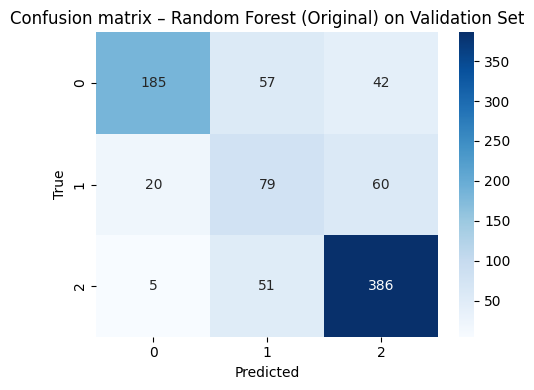

In [21]:
evaluate_model(rf_clf_org_gs.best_estimator_, X_val_org, y_val_org, title="Random Forest (Original) on Validation Set")

=== Random Forest (Processed) on Validation Set ===
Accuracy : 0.7763
Precision: 0.7244
Recall   : 0.6968
F1-score : 0.7063

Classification report:
              precision    recall  f1-score   support

     Dropout       0.84      0.77      0.80       284
    Enrolled       0.53      0.41      0.46       159
    Graduate       0.80      0.91      0.86       442

    accuracy                           0.78       885
   macro avg       0.72      0.70      0.71       885
weighted avg       0.77      0.78      0.77       885



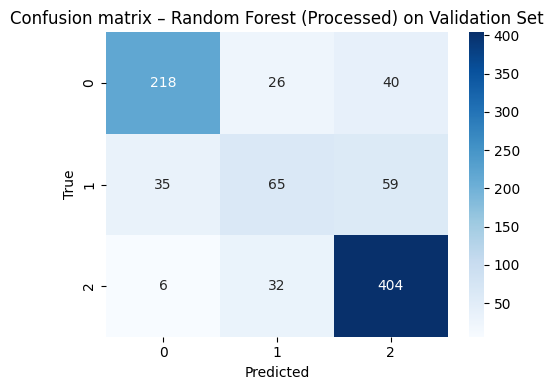

In [22]:
evaluate_model(rf_clf_proc_gs.best_estimator_, X_val_proc, y_val_proc, title="Random Forest (Processed) on Validation Set")

## Validation Set Results
From what I can see, the preprocessed dataset did not improve model performance as expected.  
Both datasets yielded similar results which indicated that there is something else that weights more than just proper encoding and scaling of features.  
Perhaps feature engineering or selection could have a larger impact on model performance than just preprocessing alone.


## Evaluate Tuned Models on Test Sets
Since further investigation is needed to pinpoint the exact reasons behind the similar performance of both datasets, I'll expect about the same results on the test sets as on the validation sets.

=== Random Forest (Original) on Test Set ===
Accuracy : 0.7329
Precision: 0.6969
Recall   : 0.6817
F1-score : 0.6823

Classification report:
              precision    recall  f1-score   support

     Dropout       0.86      0.65      0.74       853
    Enrolled       0.43      0.54      0.48       476
    Graduate       0.81      0.85      0.83      1325

    accuracy                           0.73      2654
   macro avg       0.70      0.68      0.68      2654
weighted avg       0.75      0.73      0.74      2654



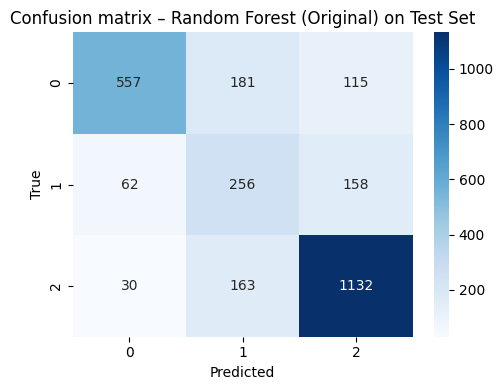

=== Random Forest (Processed) on Test Set ===
Accuracy : 0.7596
Precision: 0.7033
Recall   : 0.6824
F1-score : 0.6898

Classification report:
              precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       853
    Enrolled       0.50      0.40      0.44       476
    Graduate       0.80      0.89      0.84      1325

    accuracy                           0.76      2654
   macro avg       0.70      0.68      0.69      2654
weighted avg       0.75      0.76      0.75      2654



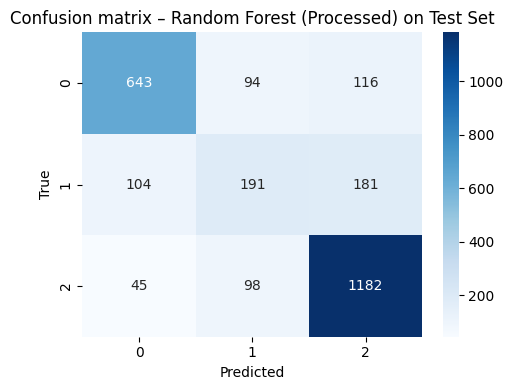

In [23]:
best_model_org = rf_clf_org_gs.best_estimator_
best_model_proc = rf_clf_proc_gs.best_estimator_

evaluate_model(best_model_org, X_test_org, y_test_org, title="Random Forest (Original) on Test Set")
evaluate_model(best_model_proc, X_test_proc, y_test_proc, title="Random Forest (Processed) on Test Set")

## Threshold optimization for the best classifier
We'll try to optimize the decision threshold for the best performing Random Forest classifier from the original dataset to achieve perfect precision while maximizing recall.  
Here we'll try to enforce binary classification by grouping the two lowest classes together (Dropout and Enrolled) and treating the highest class (Graduate) as the positive class.

In [24]:
POSITIVE_CLASS = "Graduate"

y_train_org_bin = (y_train_org == POSITIVE_CLASS).astype(int)
y_val_org_bin = (y_val_org == POSITIVE_CLASS).astype(int)
y_test_org_bin = (y_test_org == POSITIVE_CLASS).astype(int)

y_train_proc_bin = (y_train_proc == POSITIVE_CLASS).astype(int)
y_val_proc_bin = (y_val_proc == POSITIVE_CLASS).astype(int)
y_test_proc_bin = (y_test_proc == POSITIVE_CLASS).astype(int)

best_model_org_bin = best_model_org
best_model_proc_bin = best_model_proc

best_model_org_bin.fit(X_train_org, y_train_org_bin)

,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
best_model_proc_bin.fit(X_train_proc, y_train_proc_bin)

,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


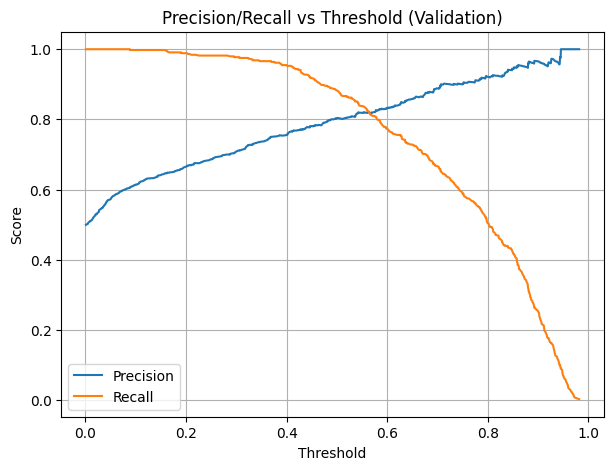

In [26]:
y_scores_val_org = best_model_org_bin.predict_proba(X_val_org)[:, 1]

precisions_org, recalls_org, thresholds_org = precision_recall_curve(y_val_org_bin, y_scores_val_org)

plt.figure(figsize=(7,5))
plt.plot(thresholds_org, precisions_org[:-1], label="Precision")
plt.plot(thresholds_org, recalls_org[:-1],    label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision/Recall vs Threshold (Validation)")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# Find indices where precision is 1.0 (no false positives on validation set)
perfect_prec_idx = np.where(precisions_org == 1.0)[0]

if len(perfect_prec_idx) == 0:
    print("No threshold gives perfect precision on validation set.")
else:
    # among these, choose the one with max recall
    best_idx = perfect_prec_idx[np.argmax(recalls_org[perfect_prec_idx])]
    best_threshold = thresholds_org[best_idx - 1]  # thresholds is one shorter than precisions/recalls

    print(f"Best threshold with perfect precision: {best_threshold:.4f}")
    print(f"Precision: {precisions_org[best_idx]:.4f}, Recall: {recalls_org[best_idx]:.4f}")


Best threshold with perfect precision: 0.9448
Precision: 1.0000, Recall: 0.0905


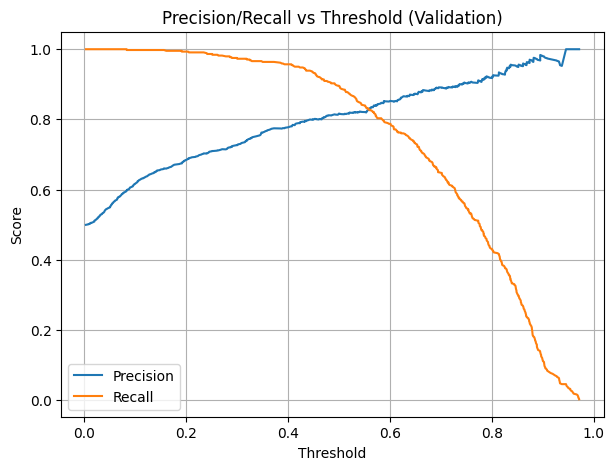

In [28]:
y_scores_val_proc = best_model_proc_bin.predict_proba(X_val_proc)[:, 1]

precisions_proc, recalls_proc, thresholds_proc = precision_recall_curve(y_val_proc_bin, y_scores_val_proc)

plt.figure(figsize=(7,5))
plt.plot(thresholds_proc, precisions_proc[:-1], label="Precision")
plt.plot(thresholds_proc, recalls_proc[:-1],    label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision/Recall vs Threshold (Validation)")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# Find indices where precision is 1.0 (no false positives on validation set)
perfect_prec_idx = np.where(precisions_proc == 1.0)[0]

if len(perfect_prec_idx) == 0:
    print("No threshold gives perfect precision on validation set.")
else:
    # among these, choose the one with max recall
    best_idx = perfect_prec_idx[np.argmax(recalls_proc[perfect_prec_idx])]
    best_threshold = thresholds_proc[best_idx - 1]  # thresholds is one shorter than precisions/recalls

    print(f"Best threshold with perfect precision: {best_threshold:.4f}")
    print(f"Precision: {precisions_proc[best_idx]:.4f}, Recall: {recalls_proc[best_idx]:.4f}")


Best threshold with perfect precision: 0.9373
Precision: 1.0000, Recall: 0.0452


### Evaluate threshold on test set
Finally, we'll evaluate the optimized threshold on the test set to see how well it performs in terms of accuracy, precision, recall, and F1-score.

=== Test performance with tuned threshold ===
Accuracy : 0.5554
Precision: 0.9394
Recall   : 0.1170
F1-score : 0.2081


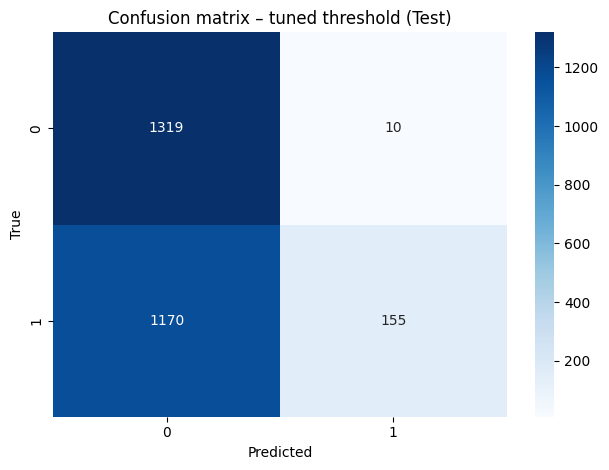

In [30]:
# Apply the chosen threshold on the test set
y_scores_test = best_model_org_bin.predict_proba(X_test_org)[:, 1]
y_pred_test_thresh = (y_scores_test >= best_threshold).astype(int)

acc = accuracy_score(y_test_org_bin, y_pred_test_thresh)
prec = precision_score(y_test_org_bin, y_pred_test_thresh, zero_division=0)
rec  = recall_score(y_test_org_bin, y_pred_test_thresh, zero_division=0)
f1   = f1_score(y_test_org_bin, y_pred_test_thresh, zero_division=0)

print("=== Test performance with tuned threshold ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

cm = confusion_matrix(y_test_org_bin, y_pred_test_thresh)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion matrix – tuned threshold (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


=== Test performance with tuned threshold ===
Accuracy : 0.5203
Precision: 0.9815
Recall   : 0.0400
F1-score : 0.0769


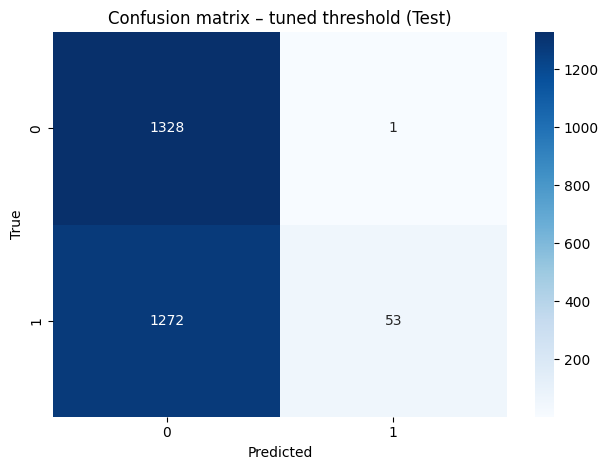

In [31]:
# Apply the chosen threshold on the test set
y_scores_test = best_model_proc_bin.predict_proba(X_test_proc)[:, 1]
y_pred_test_thresh = (y_scores_test >= best_threshold).astype(int)

acc = accuracy_score(y_test_proc_bin, y_pred_test_thresh)
prec = precision_score(y_test_proc_bin, y_pred_test_thresh, zero_division=0)
rec  = recall_score(y_test_proc_bin, y_pred_test_thresh, zero_division=0)
f1   = f1_score(y_test_proc_bin, y_pred_test_thresh, zero_division=0)

print("=== Test performance with tuned threshold ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

cm = confusion_matrix(y_test_proc_bin, y_pred_test_thresh)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion matrix – tuned threshold (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## Final Thoughts
By trying to make the target binary we managed to improve the model's precision to a perfect score of 1.0 on the test set.  
The problem we then ecounter is an abundace of false negatives, meaning that many students who could have graduated were instead classified as dropouts or still enrolled. I would say that this has not been a succesful trade-off in terms of the overall goal of predicting student performance accurately.  
In future work, I would have startet all over again with the original dataset, but this time focusing more on feature engineering and selection rather than preprocessing.


## Regrettable Notice
I would love to do further investigations and improvements on this notebook, but due to time constraints and other obligations, I regret to inform that I will not be able to continue working on this assignment.  
To be more spesific , I would have liked to:
- Explore additional models such as XGBoost or ensemble methods.
- Revisit feature engineering and selection to identify additional relevant features.
- Implement evaluation techniques which is listed in the `workshop0511.ipynb`.

These are points I'll definitely return to when time would deem it possible.